In [234]:
import pandas as pd


check to see if the data has been saved and has no missing values

In [3]:
df = pd.read_csv("cleaned_crime_data.csv")

In [4]:
df.head()

,Crime ID,Month,Reported by,Falls within,Longitude,Latitude,Location,LSOA code,LSOA name,Crime type,Last outcome category,force,year
0,e7b720d0e1302d2d06db7b28b29132eb194864d44d7921...,2024-01-01 00:00:00,City of London Police,City of London Police,-0.106220,51.518275,On or near B500,E01000916,Camden 027B,Theft from the person,Investigation complete; no suspect identified,city-of-london,2024
1,e60a5ac62a80e866453254474137c3206417422c62f0c0...,2024-01-01 00:00:00,City of London Police,City of London Police,-0.107682,51.517786,On or near B521,E01000917,Camden 027C,Other theft,Investigation complete; no suspect identified,city-of-london,2024
2,986f618142ec52b7f254e4b0549da2f17ceeb0e130db6c...,2024-01-01 00:00:00,City of London Police,City of London Police,-0.111596,51.518281,On or near Chancery Lane,E01000914,Camden 028B,Other theft,Investigation complete; no suspect identified,city-of-london,2024
3,05dc27a88748356f6d59b0bd1389710ebfb42b37e565af...,2024-01-01 00:00:00,City of London Police,City of London Police,-0.111596,51.518281,On or near Chancery Lane,E01000914,Camden 028B,Theft from the person,Status update unavailable,city-of-london,2024
4,373d78e2ccec5d05a547cd4bee19045a9e050042a0e6e7...,2024-01-01 00:00:00,City of London Police,City of London Police,-0.112096,51.515942,On or near Nightclub,E01000914,Camden 028B,Theft from the person,Investigation complete; no suspect identified,city-of-london,2024


In [5]:
df.isna().sum()

Crime ID                 0
Month                    0
Reported by              0
Falls within             0
Longitude                0
Latitude                 0
Location                 0
LSOA code                0
LSOA name                0
Crime type               0
Last outcome category    0
force                    0
year                     0
dtype: int64

Checking population data

In [7]:
pop = pd.read_csv("population_cleaned.csv")
pop

,force,population
0,west-midlands,3036605
1,essex,1929610
2,surrey,1248649
3,city-of-london,15111


At a glance we can see City of London already has the smallest population in comparison to larger areas like West Midlands and Essex

We can now see a table of a crime summary to see how overall the forces are with the number of crimes,the population size and the crime rate per 1000 population

In [10]:
pop['force'].unique()

array(['west-midlands', 'essex', 'surrey', 'city-of-london'], dtype=object)

In [11]:
crime_summary = df["force"].value_counts().rename("Crimes").reset_index()
merged = crime_summary.merge(pop,on="force",how="left")
merged["Crime_rate_per_1000"] = merged["Crimes"] / merged["population"] * 1000

merged

,force,Crimes,population,Crime_rate_per_1000
0,west-midlands,677300,3036605,223.045144
1,essex,316905,1929610,164.232669
2,surrey,172999,1248649,138.548944
3,city-of-london,17820,15111,1179.273377


<a name="anchorInstall" style="position:absolute;"></a>
<hr style="border:2px solid">

# Identify most/least desirable locations and provide insights to support sales strategy
<hr style="border-top:1px dashed">

<a name="anchorInstall" style="position:absolute;"></a>
<hr style="border:2px solid">

# Crime rate per 1000 population
<hr style="border-top:1px dashed">

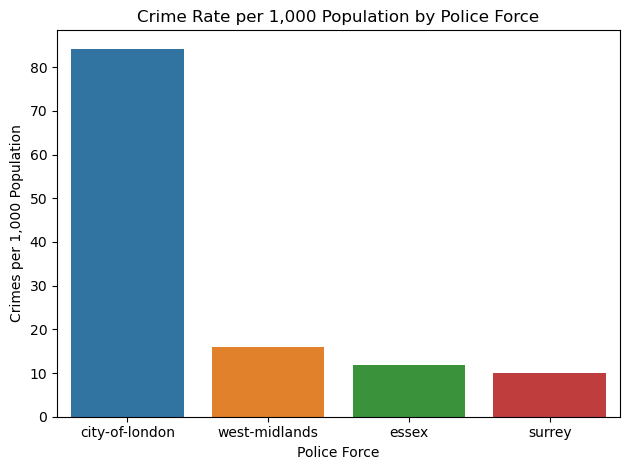

In [236]:
import matplotlib.pyplot as plt
%matplotlib inline
from scipy import stats
import seaborn as sns

#barplot showing crime rate per 1000 population for each police force sorted from highest crime to lowest
sns.barplot(
    data=merged.sort_values("Crime_rate_per_1000",ascending=False),
    x="force",
    y="Crime_rate_per_1000",
    errorbar=None,
    hue = "force"
)


plt.title("Crime Rate per 1,000 Population by Police Force")
plt.ylabel("Crimes per 1,000 Population")
plt.xlabel("Police Force")
plt.xticks()
plt.tight_layout()
plt.show()


This shows that city of london has a extremely high crime rate despite its tiny population in comparison to the others where the city is known for a huge population of workers and tourists
West midlands has the highest crime rate among the other 3 large forces indicating a higher risk for buys
Surrey has the lowest crime rate meaning its a high value,low-crine residential area


<a name="anchorInstall" style="position:absolute;"></a>
<hr style="border:2px solid">

# Top 5 Crime Types
<hr style="border-top:1px dashed">

In [17]:
df["Crime type"].nunique()

14

In [18]:
crime_counts = df["Crime type"].value_counts()


In [19]:
#Crime counts per crime type
crime_counts = df["Crime type"].value_counts()

# Total population across all forces
total_population = pop["population"].sum()

# Crime rate per 1,000 population
crime_rate_per_1000 = (crime_counts / total_population) * 1000

# Top 5 crime types
top5 = (
    crime_rate_per_1000
    .sort_values(ascending=False)
    .head(5)
)
#  Convert to DataFrame
top5_df = top5.reset_index()
top5_df.columns = ["Crime type","Crime_rate_per_1000"]


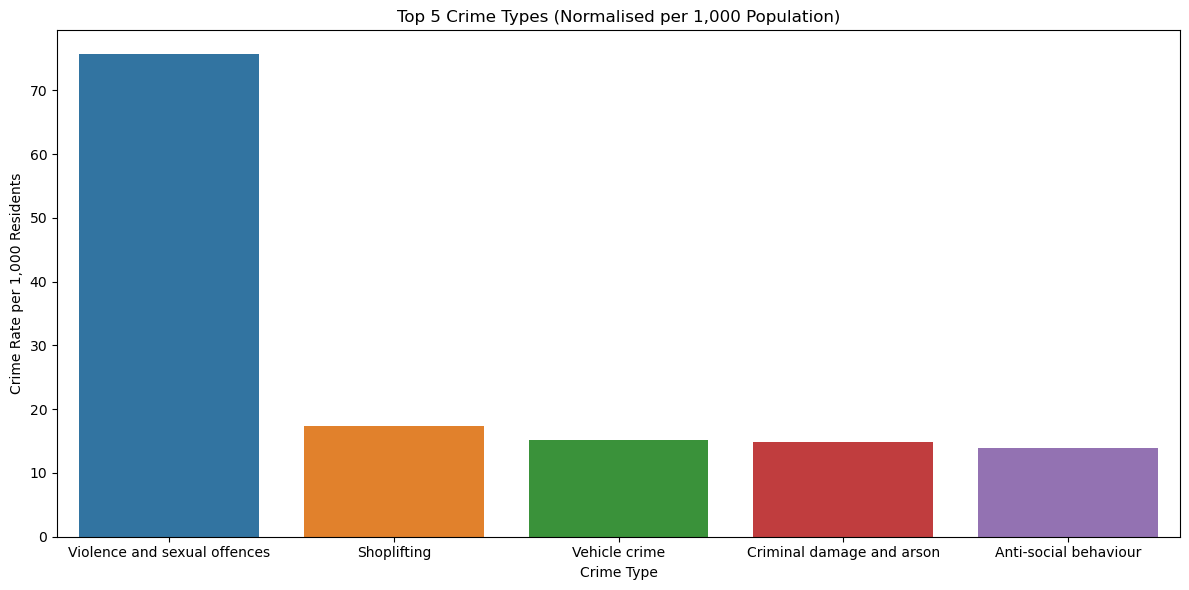

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# barplot showing top 5 crime types normalised per 1000 population
plt.figure(figsize=(12,6))
sns.barplot(
    data=top5_df,
    x="Crime type",
    y="Crime_rate_per_1000",
    hue="Crime type"
)
plt.title("Top 5 Crime Types (Normalised per 1,000 Population)")
plt.ylabel("Crime Rate per 1,000 Residents")
plt.xlabel("Crime Type")
plt.tight_layout()
plt.show()



Overall Violence and sexual offences are the most common category overall followed by anti-social behavious and shoplifting.
Next we need to look at it regionally and how it affects the specific region.
High levels of anti social behaviour would reduce neighbourhood desirability,and high vehicle crime affects areas with on-street parking.
A high burglary is a major concern for investors.

##top crime type counts per force

In [239]:
#calculating the number of crimes for each combination of police force and crime type
#creating groups by force and crime type
crime_type_counts = (
    df.groupby(["force","Crime type"])
      .size()
      .reset_index(name="Crimes")
)


In [240]:
#merging crime count with population data to normalise it
crime_type_rates = crime_type_counts.merge(pop,on="force",how="left")



In [243]:
#crime rate per 1,000 people using formula (number of crimes/ population) * 1000
crime_type_rates["Crime_rate_per_1000"] = (
    crime_type_rates["Crimes"] / crime_type_rates["population"]*1000
)


In [245]:
crime_type_rates

,force,Crime type,Crimes,population,Crime_rate_per_1000
0,city-of-london,Anti-social behaviour,349,15111,23.095758
1,city-of-london,Bicycle theft,500,15111,33.088479
2,city-of-london,Burglary,787,15111,52.081265
3,city-of-london,Criminal damage and arson,675,15111,44.669446
4,city-of-london,Drugs,936,15111,61.941632
5,city-of-london,Other crime,203,15111,13.433922
6,city-of-london,Other theft,3754,15111,248.428297
7,city-of-london,Possession of weapons,127,15111,8.404474
8,city-of-london,Public order,1307,15111,86.493283
9,city-of-london,Robbery,403,15111,26.669314


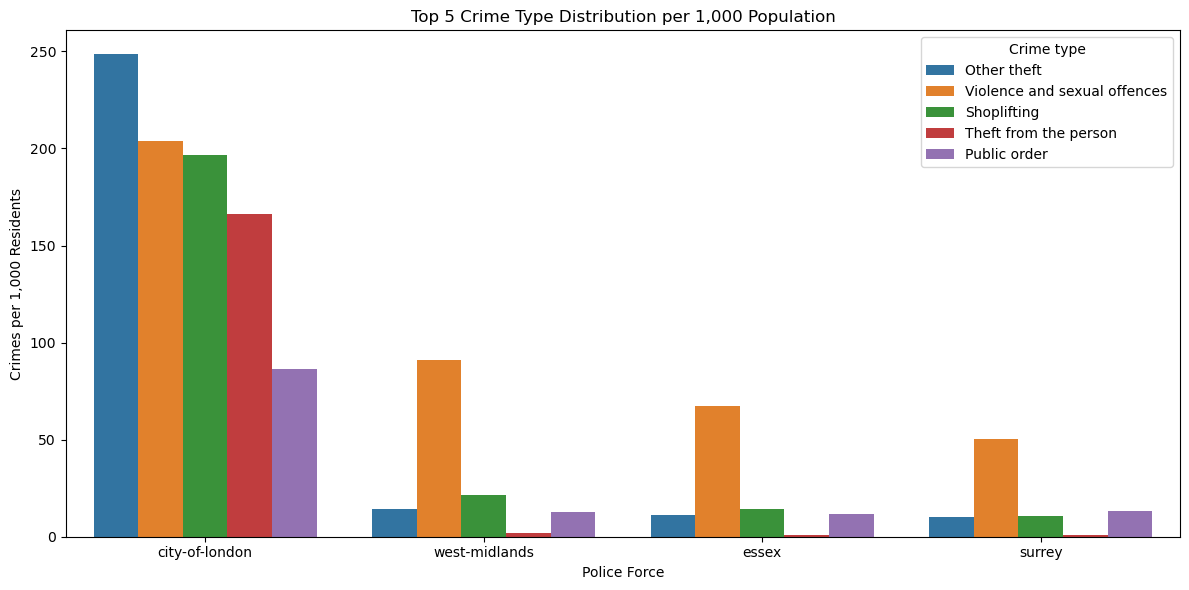

In [247]:
# to identify top 5 crime types across all forces group crime type calculate mean and sort to then select the top 5 crime types
top5_types = (
    crime_type_rates.groupby("Crime type")["Crime_rate_per_1000"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

#filter the dataframe to only comtain rows in top 5 crime types
top5_df = crime_type_rates[crime_type_rates["Crime type"].isin(top5_types)]


plt.figure(figsize=(12,6))
sns.barplot(
    data=top5_df.sort_values("Crime_rate_per_1000",ascending=False),
    x="force",
    y="Crime_rate_per_1000",
    hue="Crime type",
    errorbar=None
)
plt.title("Top 5 Crime Type Distribution per 1,000 Population")
plt.ylabel("Crimes per 1,000 Residents")
plt.xlabel("Police Force")
plt.tight_layout()
plt.show()


<a name="anchorInstall" style="position:absolute;"></a>
<hr style="border:2px solid">

# Monthly Crime Trend (Stability)
<hr style="border-top:1px dashed">

In [249]:
#converting month to data time format and creating a monthly period column 
df["Month"] = pd.to_datetime(df["Month"])
df["Month_period"] = df["Month"].dt.to_period("M")
monthly_force = (
    df.groupby(["Month_period","force"])
    .size()
    .reset_index(name="Crimes")
)


In [250]:
#merging population data to population data to normalise data
monthly_force = monthly_force.merge(pop,on="force",how="left")



In [251]:
#calculating crime rate per 1000 population
monthly_force["Crime_rate_per_1000"] = (
    monthly_force["Crimes"] / monthly_force["population"] * 1000
)
monthly_force

,Month_period,force,Crimes,population,Crime_rate_per_1000
0,2024-01,city-of-london,654,15111,43.279730
1,2024-01,essex,12823,1929610,6.645384
2,2024-01,surrey,6861,1248649,5.494739
3,2024-01,west-midlands,27055,3036605,8.909621
4,2024-02,city-of-london,762,15111,50.426841
...,...,...,...,...,...
95,2025-12,west-midlands,24236,3036605,7.981282
96,2026-01,city-of-london,659,15111,43.610615
97,2026-01,essex,11899,1929610,6.166531
98,2026-01,surrey,6288,1248649,5.035843


In [255]:
#checks
monthly_force["Month_period"].head()
monthly_force["Month_period"].dtype
monthly_force["Month_period"] = monthly_force["Month_period"].dt.to_timestamp()




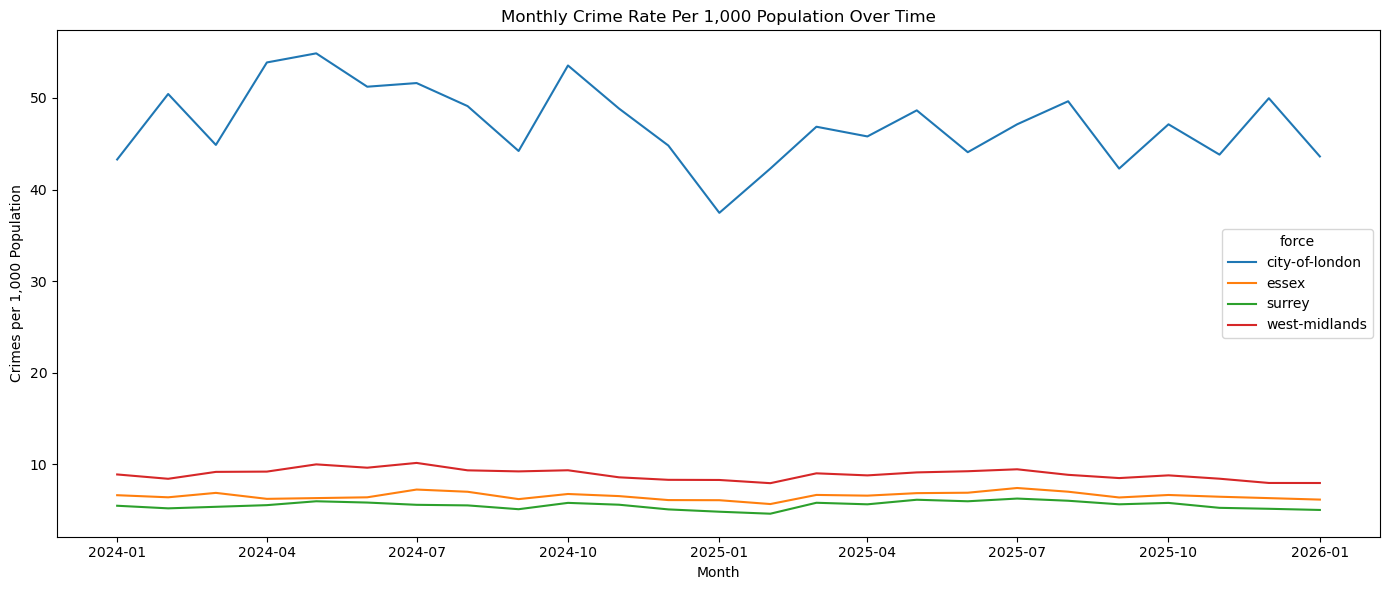

In [257]:
plt.figure(figsize=(14,6))
#line chart to see monthly crime rate per 1000 population for each police force
sns.lineplot(
    data=monthly_force,
    x="Month_period",
    y="Crime_rate_per_1000",
    hue="force"
)

plt.title("Monthly Crime Rate Per 1,000 Population Over Time")
plt.ylabel("Crimes per 1,000 Population")
plt.xlabel("Month")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



## map densities with map location

In [274]:
#grouping police force and location for the barcharts with map densities
lsoa_summary = (
    df.groupby(["force","Location"])
      .size()
      .reset_index(name="Crime_count")
      .sort_values(["force","Crime_count"],ascending=[True,False])
)
lsoa_summary

,force,Location,Crime_count
351,city-of-london,On or near Shopping Area,1046
386,city-of-london,On or near Supermarket,654
47,city-of-london,On or near Bishopsgate,615
414,city-of-london,On or near Victoria Avenue,580
245,city-of-london,On or near Liverpool Street,529
...,...,...,...
44459,west-midlands,On or near Wychall Drive,1
44541,west-midlands,On or near Yarnborough Hill,1
44543,west-midlands,On or near Yarner Close,1
44554,west-midlands,On or near Yates Lane,1


In [276]:
#filters to one police force to take top 10 sorted by highest crime rate
def top_lsoas_table(force_name):
    subset = (
        lsoa_summary[lsoa_summary["force"] == force_name]
        .sort_values("Crime_count",ascending=False)
        .head(10)
    )
    return subset


In [278]:
top_lsoas_table("city-of-london")


,force,Location,Crime_count
351,city-of-london,On or near Shopping Area,1046
386,city-of-london,On or near Supermarket,654
47,city-of-london,On or near Bishopsgate,615
414,city-of-london,On or near Victoria Avenue,580
245,city-of-london,On or near Liverpool Street,529
287,city-of-london,On or near New Street,360
105,city-of-london,On or near Conference/Exhibition Centre,358
96,city-of-london,On or near Circus Place,331
109,city-of-london,On or near Corbet Court,305
276,city-of-london,On or near Moor Lane,303


In [282]:
#crime density map filtered by a police force
def plot_hexbin(force_name):
    subset = df[df["force"] == force_name]

    plt.figure(figsize=(8,8))
    plt.hexbin(
        subset["Longitude"],
        subset["Latitude"],
        gridsize=40,
        cmap="viridis",
        mincnt=1
    )

    plt.colorbar(label="Crime density")
    plt.title(f"Crime Density Map: {force_name}")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.tight_layout()
    plt.show()

#barcharts for the locations of the crimes for each force

def plot_top_lsoas(force_name,n=10):
    subset = lsoa_summary[lsoa_summary["force"] == force_name]
    subset = subset.sort_values("Crime_count",ascending=False).head(n)

    plt.figure(figsize=(10,6))
    sns.barplot(
        data=subset,
        x="Crime_count",
        y="Location",
        hue="Location"
    )
    plt.title(f"Top {n} LSOAs by Crime Count: {force_name}")
    plt.xlabel("Crime Count")
    plt.ylabel("Location")
    plt.tight_layout()
    plt.show()




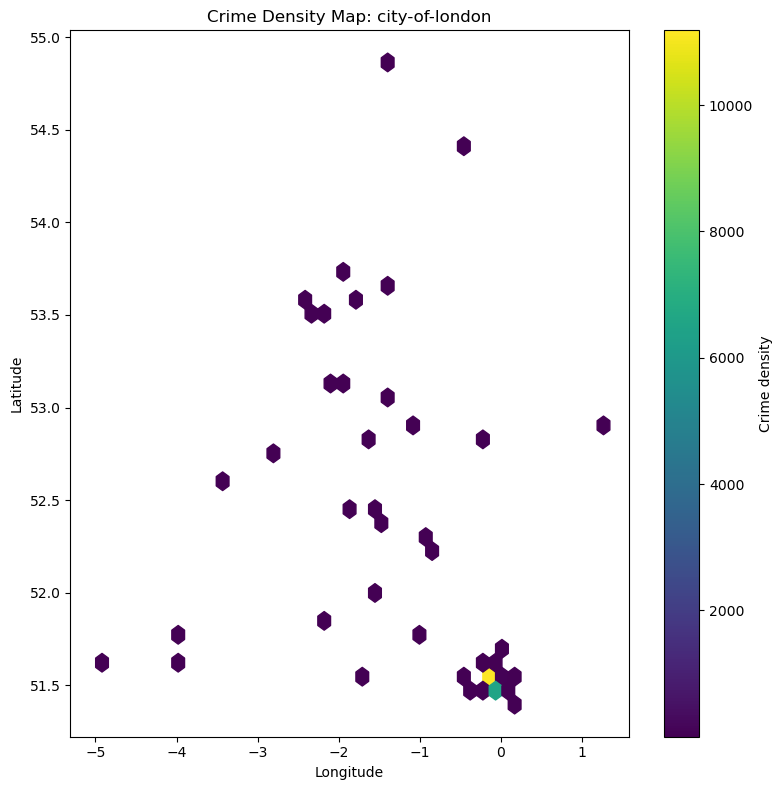

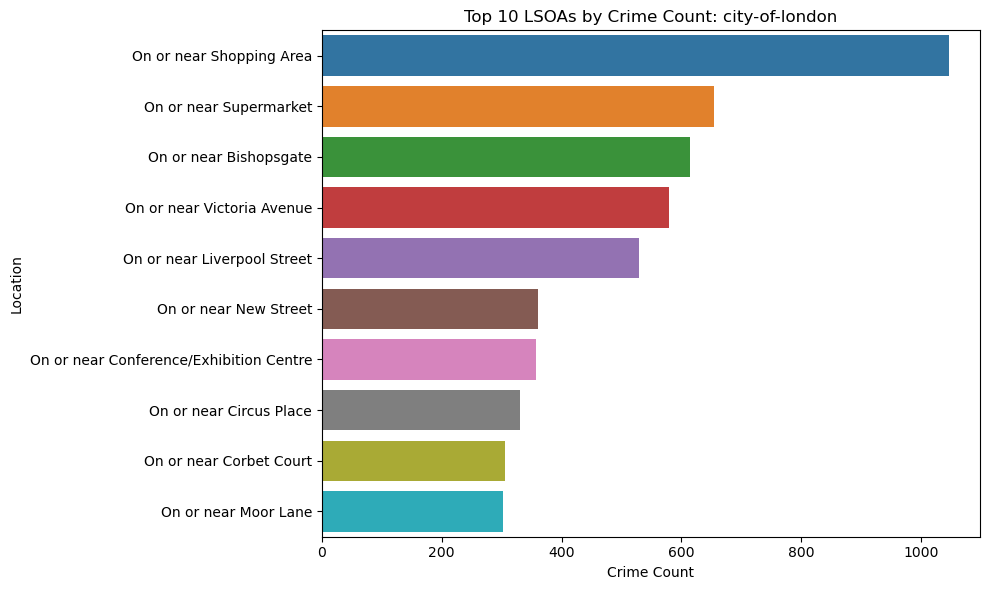

In [284]:
plot_hexbin("city-of-london")
plot_top_lsoas("city-of-london")


The hexbin map highlights where the crimes cluster within cty of london to reveal hotspots. this shows a strng spacial clustering where it seems more concentrated around the central core. The brightest core represents high-volumee hotspots which helps identify where policing zones would be important to ensure safety, and within this majority of the crimes fall wthin shopping areas and supermarkets which are quite heavy in the city

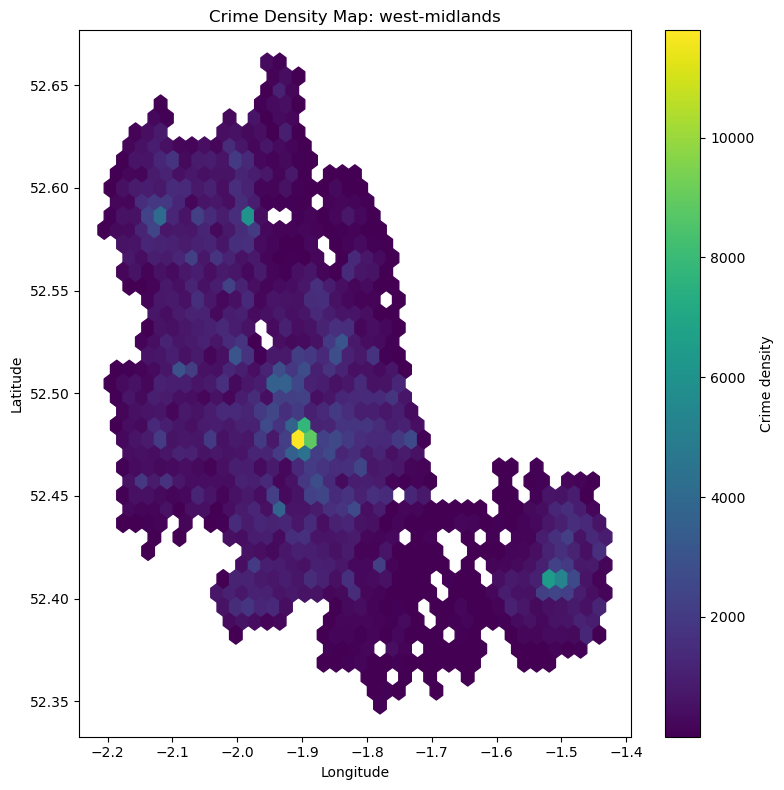

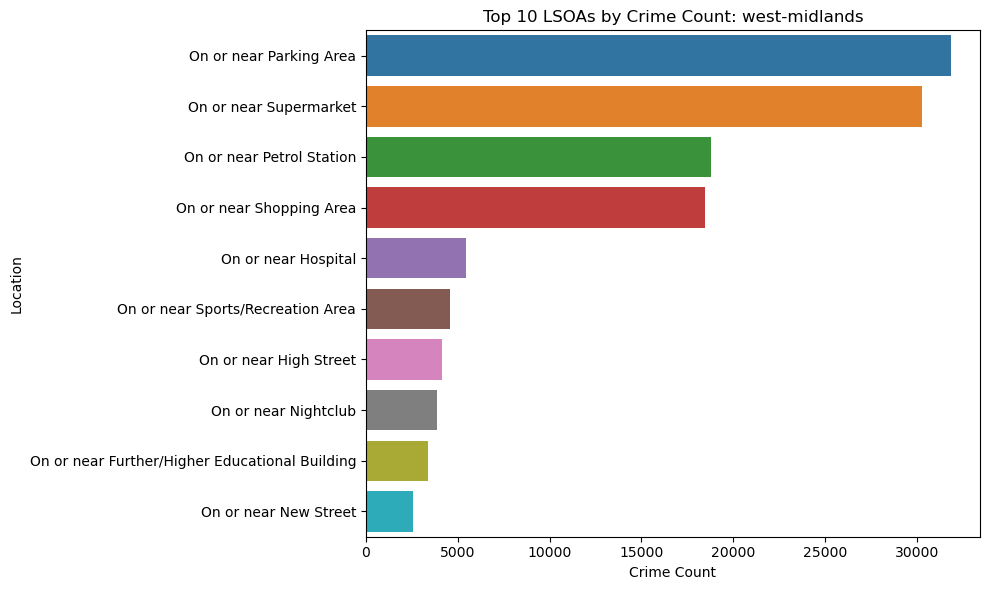

In [286]:

plot_hexbin("west-midlands")
plot_top_lsoas("west-midlands")

the hexbin chart firstly shows a high concentration crime hotspots centred around mid birmingham which reflects the regions population distribution and the amount of commercial,retail,and transport within birmingham. As distance from the hotspot increaes, crime density drops off quickly which may be due to the centre having major shopping districts and transport hubs like railways, The bar chart reveals the crime dominated in west midlands include parking areas, near supermarkets, petrol stations and near shopping area which usualy attract large crouds increasing opportunities for crime.

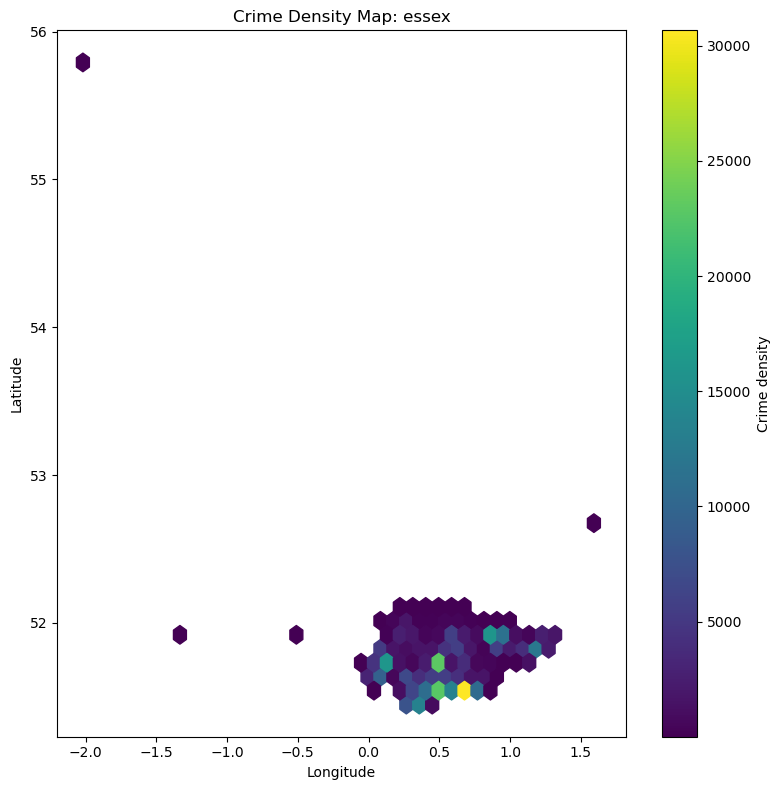

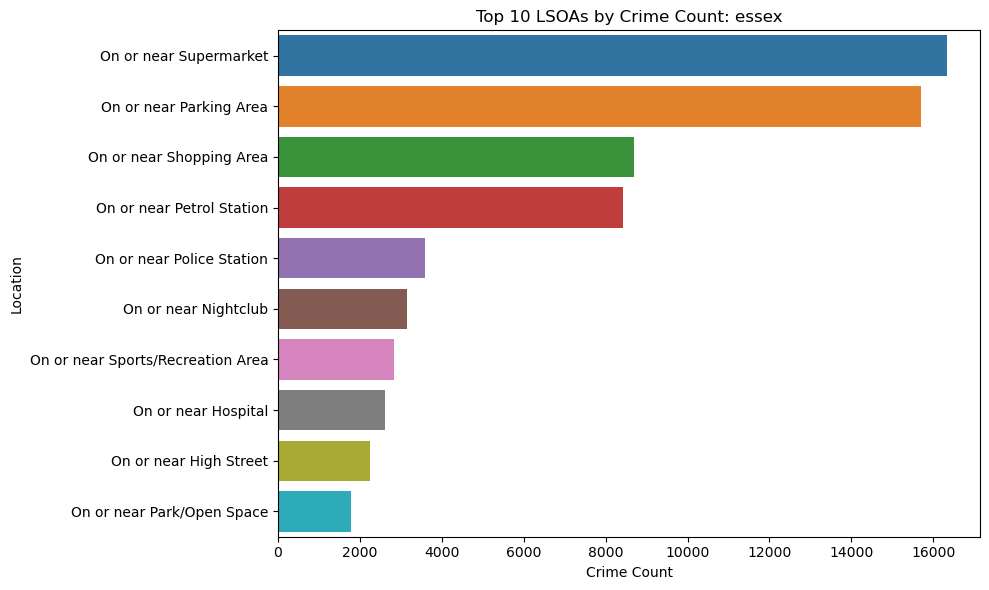

In [288]:

plot_hexbin("essex")
plot_top_lsoas("essex")

The hexbin shows Essex has several distinct clusters spread across where the highest crime locations include near supermarket, parking area or near shopping area and petrol stations which has alot of people and behicle movements which plays a major role in essects crime profile as shop lifting appears as one of the most crime types.

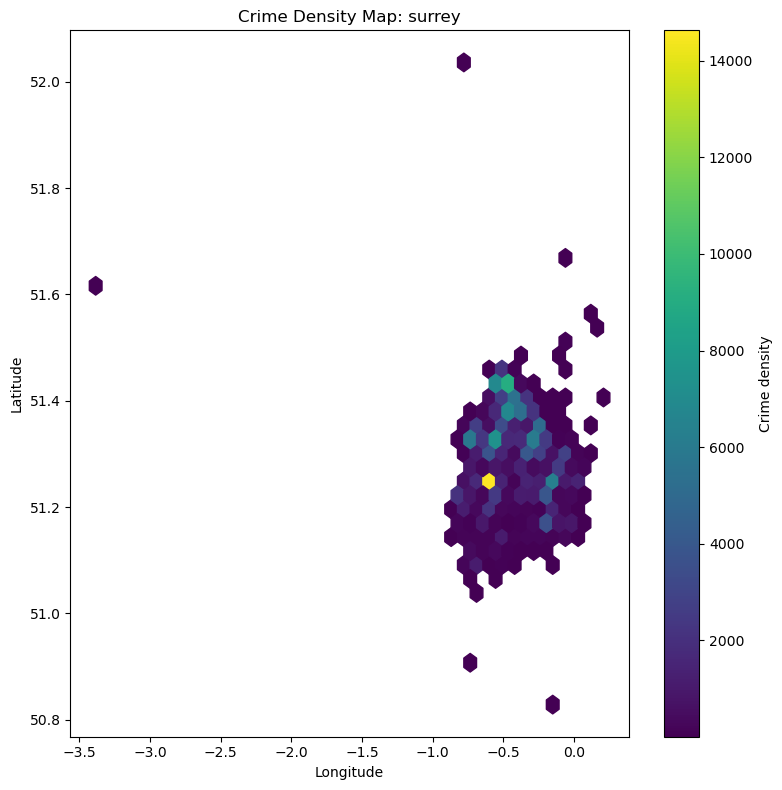

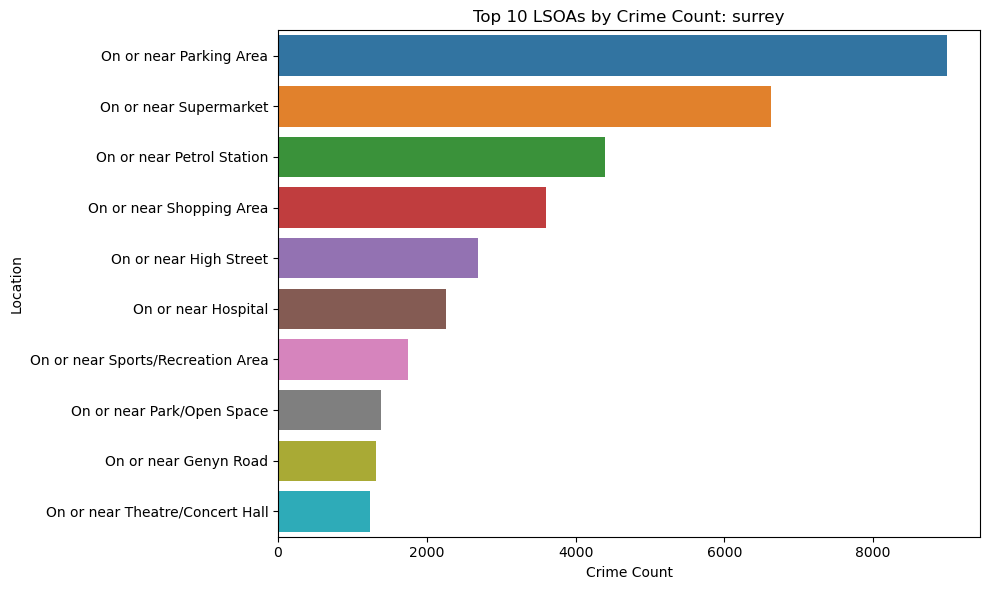

In [290]:
plot_hexbin("surrey")
plot_top_lsoas("surrey")


This hexbin map shows that crime in Surrey is highly unevenly distributed , with alot of incidents in a small part of the county. The chart shows that Surreys crime is driven by parking areas, supermarkets, petrol stations and shopping areas which reflects alot of people and commercial activity .

In [199]:
location_lsoa_summary = (
    df.groupby(["force","Location","LSOA name"])
      .size()
      .reset_index(name="Crime_count")
)
location_lsoa_summary



,force,Location,LSOA name,Crime_count
0,city-of-london,On or near A1,City of London 001A,72
1,city-of-london,On or near A10,City of London 001F,53
2,city-of-london,On or near A1006,Waltham Forest 018D,1
3,city-of-london,On or near A1210,City of London 001E,7
4,city-of-london,On or near A1240,Barking and Dagenham 013A,1
...,...,...,...,...
60712,west-midlands,On or near Zion Street,Sandwell 007A,22
60713,west-midlands,On or near Zions Close,Sandwell 035C,1
60714,west-midlands,On or near Zoar Street,Dudley 008C,22
60715,west-midlands,On or near Zoar Street,Wolverhampton 020B,16


In [292]:
import geopandas as gpd
#loading map file
lsoa = gpd.read_file("map-data/map.geojson")
lsoa.head()


,FID,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry
0,1,E01000001,City of London 001A,,532123,181632,51.51817,-0.097150,3478c558-3297-4e2b-979e-e29dd9ff3bf5,"POLYGON ((-0.094744 51.521, -0.095455 51.515, ..."
1,2,E01000002,City of London 001B,,532480,181715,51.51883,-0.091970,f2072109-b1ae-426c-b166-083cc32f1789,"POLYGON ((-0.088103 51.519, -0.095455 51.515, ..."
2,3,E01000003,City of London 001C,,532239,182033,51.52174,-0.095330,a9009c33-9b6b-4230-ba62-fc3264806de4,"POLYGON ((-0.094533 51.522, -0.092737 51.521, ..."
3,4,E01000005,City of London 001E,,533581,181283,51.51469,-0.076280,86aee0aa-079f-4f92-8f9d-5773824f4945,"POLYGON ((-0.075892 51.516, -0.073943 51.514, ..."
4,5,E01000006,Barking and Dagenham 016A,,544994,184274,51.53875,0.089317,c33f1f5b-6b15-47a1-b046-b6a148a9f6d3,"POLYGON ((0.093284 51.538, 0.093626 51.538, 0...."


In [ ]:
#total crimes per lsoa code
crime_lsoa = (
    df.groupby("LSOA code")
      .size()
      .reset_index(name="Crimes")
)



<Figure size 1200x1200 with 0 Axes>

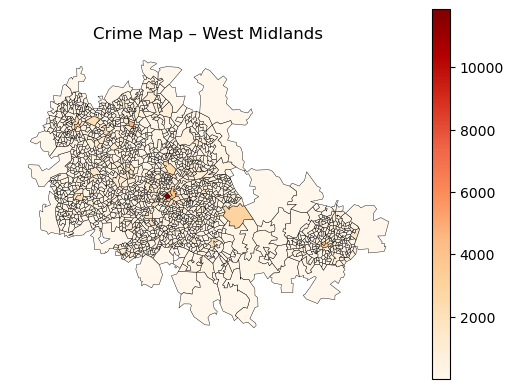

In [294]:
#count crimes per police force and losa name for mapping
lsoa_summary = (
    df.groupby(["force","LSOA name"])
      .size()
      .reset_index(name="Crime_count")
)
#filter for west midlands
wm = lsoa_summary[lsoa_summary["force"] == "west-midlands"]

#geodataframe: joining west midlands crime counts to the lsoa shape file
gdf = lsoa.merge(
    wm,
    left_on="LSOA21NM",
    right_on="LSOA name",
    how="left"
)

gdf[["LSOA21NM","LSOA name","Crime_count"]]
#only lsoas that belong in the selected force unique names
force_lsoas = wm["LSOA name"].unique()
gdf_force = gdf[gdf["LSOA21NM"].isin(force_lsoas)]

plt.figure(figsize=(12,12))
gdf_force.plot(
    column="Crime_count",
    cmap="OrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.3
)
plt.title("Crime Map – West Midlands")
plt.axis("off")
plt.show()


hexbin diagram as a map to show where central hotspot is

In [296]:
#count crime per lsoa
lsoa_summary = (
    df.groupby("LSOA name")
      .size()
      .reset_index(name="Crime_count")
)
#merge crime counts to lsoa shapefile
gdf = lsoa.merge(
    lsoa_summary,
    left_on="LSOA21NM",
    right_on="LSOA name",
    how="left"
)
gdf


,FID,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry,LSOA name,Crime_count
0,1,E01000001,City of London 001A,,532123,181632,51.51817,-0.097150,3478c558-3297-4e2b-979e-e29dd9ff3bf5,"POLYGON ((-0.094744 51.521, -0.095455 51.515, ...",City of London 001A,305.0
1,2,E01000002,City of London 001B,,532480,181715,51.51883,-0.091970,f2072109-b1ae-426c-b166-083cc32f1789,"POLYGON ((-0.088103 51.519, -0.095455 51.515, ...",City of London 001B,825.0
2,3,E01000003,City of London 001C,,532239,182033,51.52174,-0.095330,a9009c33-9b6b-4230-ba62-fc3264806de4,"POLYGON ((-0.094533 51.522, -0.092737 51.521, ...",City of London 001C,231.0
3,4,E01000005,City of London 001E,,533581,181283,51.51469,-0.076280,86aee0aa-079f-4f92-8f9d-5773824f4945,"POLYGON ((-0.075892 51.516, -0.073943 51.514, ...",City of London 001E,1345.0
4,5,E01000006,Barking and Dagenham 016A,,544994,184274,51.53875,0.089317,c33f1f5b-6b15-47a1-b046-b6a148a9f6d3,"POLYGON ((0.093284 51.538, 0.093626 51.538, 0....",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
35667,35668,W01002036,Vale of Glamorgan 005G,Bro Morgannwg 005G,317939,172435,51.44494,-3.182180,f79ed9c6-8220-49d9-9a69-e80e9f0007cb,"POLYGON ((-3.1771 51.447, -3.1762 51.443, -3.1...",NaN,NaN
35668,35669,W01002037,Vale of Glamorgan 005H,Bro Morgannwg 005H,318527,172406,51.44476,-3.173710,fdd8e9dc-8504-4955-aa8d-e4cff563ed76,"POLYGON ((-3.1665 51.447, -3.1718 51.443, -3.1...",NaN,NaN
35669,35670,W01002038,Vale of Glamorgan 014G,Bro Morgannwg 014G,306491,167360,51.39754,-3.345520,7b56d7b1-48e6-4883-a46e-3bd00345bc8c,"POLYGON ((-3.3434 51.39, -3.3493 51.387, -3.35...",NaN,NaN
35670,35671,W01002039,Vale of Glamorgan 014H,Bro Morgannwg 014H,306564,166023,51.38553,-3.344120,36d00276-9970-4f4b-9322-5b89fdacf0c3,"POLYGON ((-3.3358 51.383, -3.3387 51.382, -3.3...",NaN,NaN


In [298]:
#uncomment map to view the zoomable map
#filtering data to city of london
df_city_geo = df[
    (df["Reported by"]=="City of London Police") &
    (df["Falls within"]=="City of London Police")
].copy()
lsoa_summary = (
    df_city_geo.groupby("LSOA name")
               .size()
               .reset_index(name="Crime_count")
)

gdf_city = lsoa.merge(
    lsoa_summary,
    left_on="LSOA21NM",
    right_on="LSOA name",
    how="left"
)

import folium
from folium import Choropleth

m = folium.Map(location=[51.515,-0.09],zoom_start=14,tiles="cartodbpositron")

Choropleth(
    geo_data=gdf_city,
    data=gdf_city,
    columns=["LSOA21NM","Crime_count"],
    key_on="feature.properties.LSOA21NM",
    fill_color="YlOrRd",
    fill_opacity=0.8,
    line_opacity=0.6,
    nan_fill_color="white"
).add_to(m)

#m



The map shows that crime in the city of london is extremely concentrated within a small area, where crime is clusterd arount the main city where all public activity remains high. This makes the city stand out as despite the small population it has a large hotspot of crimes.

In [299]:
#uncomment map call to view the zoomable map
# Filter  to west midlands police
df_wm_geo = df[
    (df["Reported by"] == "West Midlands Police") &
    (df["Falls within"] == "West Midlands Police")
].copy()

# Group by LSOA
lsoa_summary_wm = (
    df_wm_geo.groupby("LSOA name")
             .size()
             .reset_index(name="Crime_count")
)

# Merge with boundaries
gdf_wm = lsoa.merge(
    lsoa_summary_wm,
    left_on="LSOA21NM",
    right_on="LSOA name",
    how="left"
)

# map
m_wm = folium.Map(location=[52.48,-1.89],zoom_start=10,tiles="cartodbpositron")

Choropleth(
    geo_data=gdf_wm,
    data=gdf_wm,
    columns=["LSOA21NM","Crime_count"],
    key_on="feature.properties.LSOA21NM",
    fill_color="YlOrRd",
    fill_opacity=0.8,
    line_opacity=0.6,
    nan_fill_color="white"
).add_to(m_wm)

#m_wm


this map highlights how crime intensity varies where the deep red areas are clustered around birmingham which reflects the amount of retail, commercial and transport activities. As moving outward from the centre it becoemes lighter indicating a rapid decline in intenisty across suburban and semi rural areas.

In [300]:
#uncomment map to view the zoomable map
# Filter Essex police
df_essex_geo = df[
    (df["Reported by"] == "Essex Police") &
    (df["Falls within"] == "Essex Police")
].copy()

# Group by LSOA
lsoa_summary_essex = (
    df_essex_geo.groupby("LSOA name")
                .size()
                .reset_index(name="Crime_count")
)

# Merge with boundaries
gdf_essex = lsoa.merge(
    lsoa_summary_essex,
    left_on="LSOA21NM",
    right_on="LSOA name",
    how="left"
)

# Folium map
m_essex = folium.Map(location=[51.77,0.45],zoom_start=9,tiles="cartodbpositron")

Choropleth(
    geo_data=gdf_essex,
    data=gdf_essex,
    columns=["LSOA21NM","Crime_count"],
    key_on="feature.properties.LSOA21NM",
    fill_color="YlOrRd",
    fill_opacity=0.8,
    line_opacity=0.6,
    nan_fill_color="white"
).add_to(m_essex)

#m_essex


this chart shows fewer high intensity crime areas but dispersed at lower levels across the regions particularly around southend on sea, chelmsford, basildon and colchester .

In [301]:
# Filter to Surrey police only
df_surrey_geo = df[
    (df["Reported by"] == "Surrey Police") &
    (df["Falls within"] == "Surrey Police")
].copy()

# Group by LSOA
lsoa_summary_surrey = (
    df_surrey_geo.groupby("LSOA name")
                 .size()
                 .reset_index(name="Crime_count")
)

# Merge with boundaries
gdf_surrey = lsoa.merge(
    lsoa_summary_surrey,
    left_on="LSOA21NM",
    right_on="LSOA name",
    how="left"
)

#map
m_surrey = folium.Map(location=[51.25,-0.45],zoom_start=10,tiles="cartodbpositron")

Choropleth(
    geo_data=gdf_surrey,
    data=gdf_surrey,
    columns=["LSOA21NM","Crime_count"],
    key_on="feature.properties.LSOA21NM",
    fill_color="YlOrRd",
    fill_opacity=0.8,
    line_opacity=0.6,
    nan_fill_color="white"
).add_to(m_surrey)

#m_surrey


this shows that surrey has majoriy of its county with a low crime intensity with a few small hotspots which are within commercial, or transport areas which means indicates a higher crime rate due to a a higher economic activity


In [304]:
#group crime type and police force
crime_summary2 = (
    df.groupby(["force","Crime type"])
      .size()
      .reset_index(name="Crimes")
)
#joining with population and calculating normalised crime rate
merged = crime_summary2.merge(pop,on="force",how="left")
merged["Crime_rate_per_1000"] = (
    merged["Crimes"] / merged["population"] * 1000
)

#heatmap
heatmap_data = merged.pivot(
    index="force",
    columns="Crime type",
    values="Crime_rate_per_1000"
)


In [305]:
crime_summary2

,force,Crime type,Crimes
0,city-of-london,Anti-social behaviour,349
1,city-of-london,Bicycle theft,500
2,city-of-london,Burglary,787
3,city-of-london,Criminal damage and arson,675
4,city-of-london,Drugs,936
5,city-of-london,Other crime,203
6,city-of-london,Other theft,3754
7,city-of-london,Possession of weapons,127
8,city-of-london,Public order,1307
9,city-of-london,Robbery,403


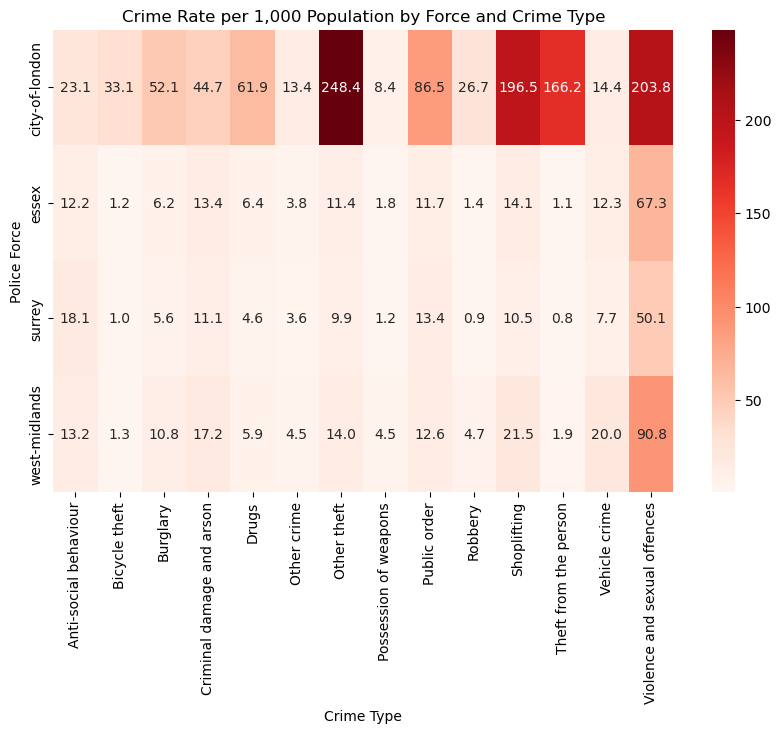

In [312]:
import seaborn as sns
import matplotlib.pyplot as plt
#plotting heatmap data
plt.figure(figsize=(10,6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="Reds",
    
)

plt.title("Crime Rate per 1,000 Population by Force and Crime Type")
plt.xlabel("Crime Type")
plt.ylabel("Police Force")
plt.show()


This heatmap shows all the crime types recorded and how much was recorded based on intensity between the 4 forces where clearly city of london demonstrates the most reported crimes normalized 1000 per population in comparison to the others.Surrey shows the least amount of crimes reported followed by essex then West midlands

<a name="anchorInstall" style="position:absolute;"></a>
<hr style="border:2px solid">

# Crime Outcomes ( how often crimes are solved)
<hr style="border-top:1px dashed">

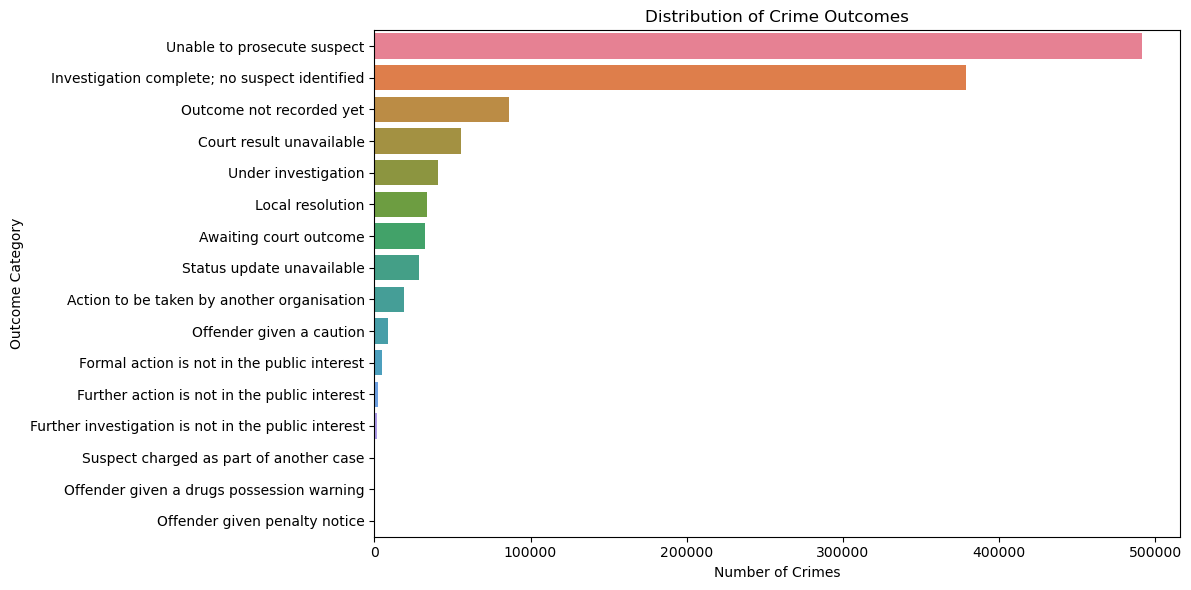

In [314]:
# Total outcomes of crimes 
outcome_counts = (
    df["Last outcome category"]
    .value_counts()
    .reset_index()
)

outcome_counts.columns = ["Outcome", "Count"]

#barchart of distribution of crime outcomes across dataset
plt.figure(figsize=(12,6))
sns.barplot(
    data=outcome_counts,
    x="Count",
    y="Outcome",
    hue="Outcome",
   
   
)

plt.title("Distribution of Crime Outcomes")
plt.xlabel("Number of Crimes")
plt.ylabel("Outcome Category")
plt.legend([],[], frameon=False)
plt.tight_layout()
plt.show()



If most crimes are "no suspect identified" it means the area may be under-policed meaning the area is less secure and not well-policed,

In [140]:
top3_per_force = (
    df.groupby(["force","Last outcome category"])
      .size()
      .reset_index(name="Count")
)

# For each force,keeping only the top 3 outcomes
top3_per_force = (
    top3_per_force
    .sort_values(["force","Count"],ascending=[True,False])
    .groupby("force")
    .head(3)
)


In [142]:
#joining with population
top3_per_force = top3_per_force.merge(
    merged[["force","population"]],
    on="force",
    how="left"
)


In [144]:
#calculating normalized outcome value
top3_per_force["Outcome_rate_per_1000"] = (
    top3_per_force["Count"] / top3_per_force["population"] * 1000
)


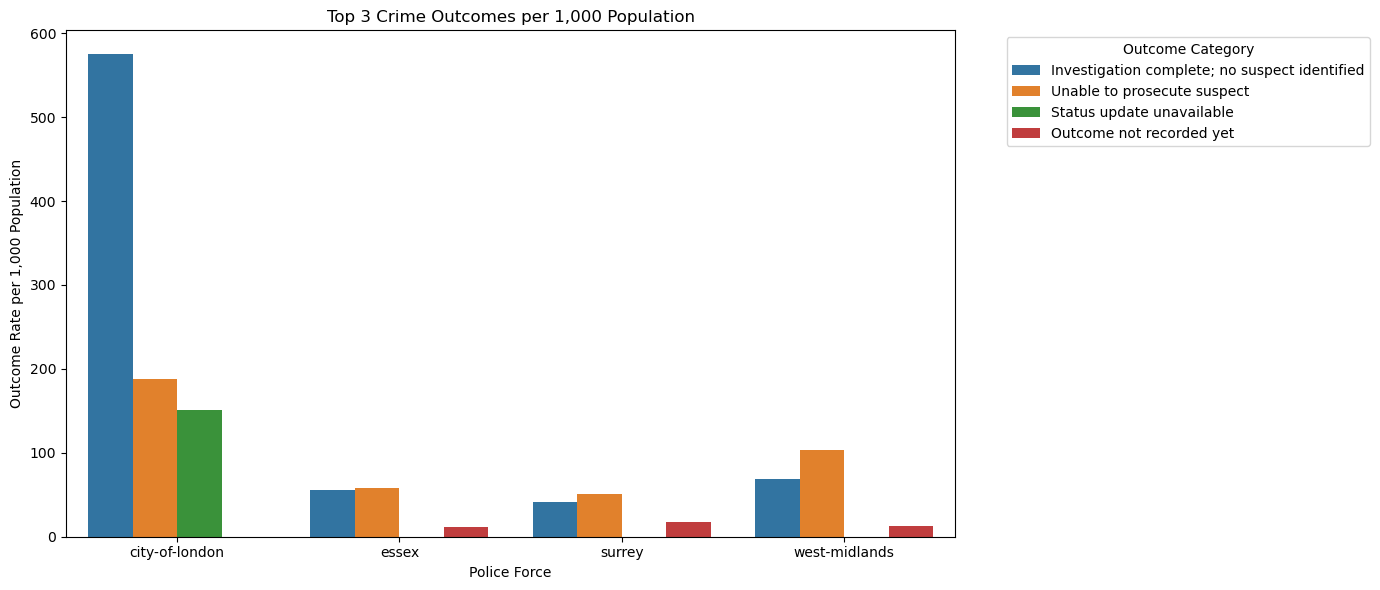

In [316]:
plt.figure(figsize=(14,6))
#barplot of top 3 outcomes per force
sns.barplot(
    data=top3_per_force,
    x="force",
    y="Outcome_rate_per_1000",
    hue="Last outcome category",
    
)

plt.title("Top 3 Crime Outcomes per 1,000 Population")
plt.ylabel("Outcome Rate per 1,000 Population")
plt.xlabel("Police Force")
plt.xticks(rotation=0)
plt.legend(title="Outcome Category",bbox_to_anchor=(1.05,1),loc="upper left")
plt.tight_layout()
plt.show()



this shows city of london having the highest non suspects identified meaning more risk of crimes unable to punish and prosecute meaning high risk, whereas surrey shows the least amount meaning within the small amount of crimes a small amount of investigation is complete with no suspects, or not able to prosecute. West midlands shows the second highest unreported but still significantly lower than the city of london 